In [2]:
##############################################################
# Fashion MNST Dataset
from tensorflow.keras.datasets import mnist
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

4422102/4422102 [==============================] - 2s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

9


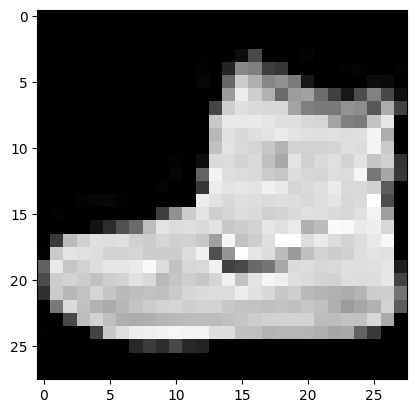

0


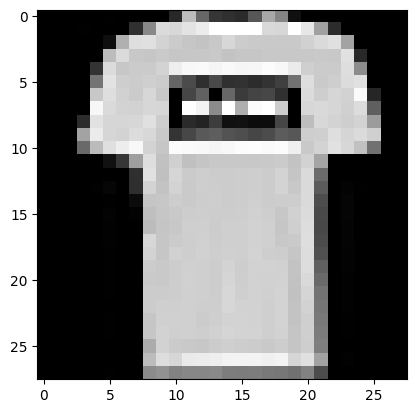

0


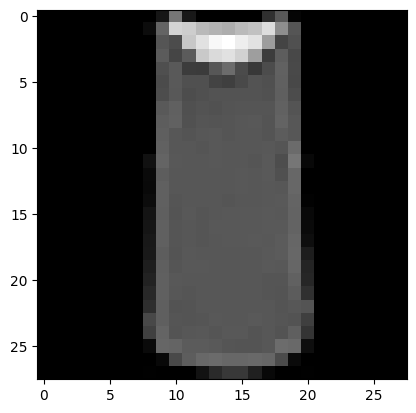

3


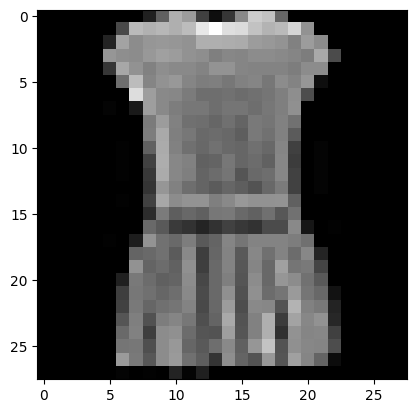

0


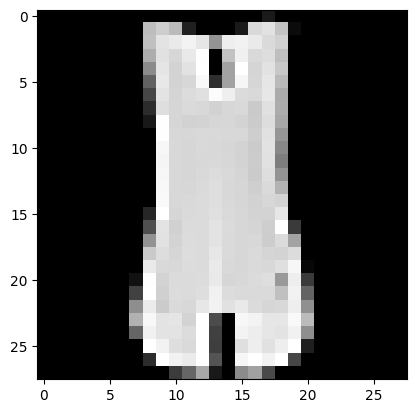

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
for i in range(5):
    img = X_train[i]
    display(Image.fromarray(img))
    print(Y_train[i])
    plt.imshow(img, cmap='gray')
    plt.show()

In [6]:
%%time
##############################################################
# 16-2 MNIST : Simple 코드 (1분 소요)
#  Test Accuracy: 0.8930
# CPU times: total: 2min 31s
# Wall time: 40.8 s
##############################################################
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()
# (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# # MNIST 데이터 불러오기
# (X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# 0 ~ 1로 정규화
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255

# One-Hot
Y_train = tf.keras.utils.to_categorical(Y_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_test, 10)

# 모델 프레임 설정 (Multi Layer Perceptron)
model = Sequential()
model.add(Dense(512, input_dim=784, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 모델 실행 환경 설정
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = 'data/model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="data/model/fashion_mnist_model.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', 
                               verbose=1, save_best_only=True)

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), 
                    epochs=30, batch_size=200, verbose=0, 
                    callbacks=[early_stopping_callback, checkpointer])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test)[1]))



Epoch 1: val_loss improved from inf to 0.43275, saving model to data/model\fashion_mnist_model.keras

Epoch 2: val_loss improved from 0.43275 to 0.37370, saving model to data/model\fashion_mnist_model.keras

Epoch 3: val_loss improved from 0.37370 to 0.36517, saving model to data/model\fashion_mnist_model.keras

Epoch 4: val_loss improved from 0.36517 to 0.34607, saving model to data/model\fashion_mnist_model.keras

Epoch 5: val_loss improved from 0.34607 to 0.33111, saving model to data/model\fashion_mnist_model.keras

Epoch 6: val_loss improved from 0.33111 to 0.32989, saving model to data/model\fashion_mnist_model.keras

Epoch 7: val_loss improved from 0.32989 to 0.32432, saving model to data/model\fashion_mnist_model.keras

Epoch 8: val_loss did not improve from 0.32432

Epoch 9: val_loss did not improve from 0.32432

Epoch 10: val_loss did not improve from 0.32432

Epoch 11: val_loss did not improve from 0.32432

Epoch 12: val_loss did not improve from 0.32432

Epoch 13: val_loss

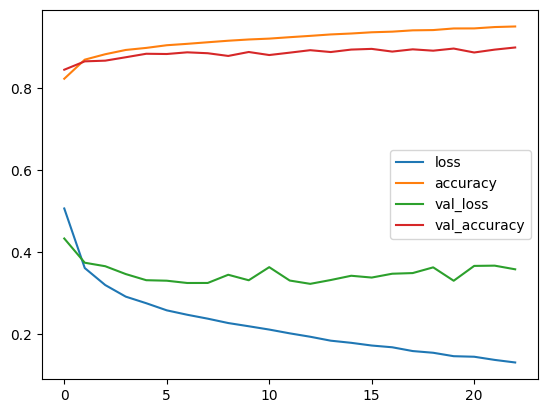

In [7]:
import pandas as pd
pd.DataFrame(history.history).plot()
plt.show()

In [8]:
X_train[0].reshape(28, 28)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [15]:
img_array = (X_train[0] * 255).astype(int).reshape(28, 28)

In [17]:
for line in img_array:
    for cell in line:
        print("%3d" % cell, end=' ')
    print()

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3 
  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15 
  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66 
  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 223 215 213 164 127 

In [18]:
labels = ['T-shirt/top', 'Trouser', 
'Pullover', 'Dress', 'Coat', 'Sandal', 
          'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

1/1 [==============================] - 0s 23ms/step
Y값 = 9 Ankle boot
예측값 = 9 Ankle boot
###### 정답!!! ######


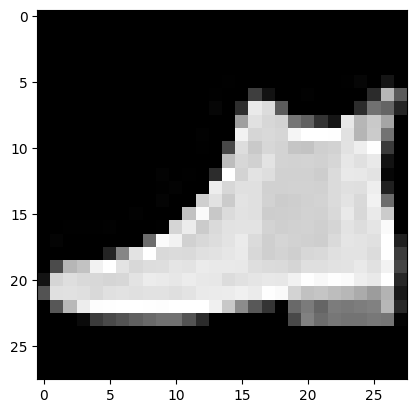

In [21]:
###############################################################
# 검증하기 : n번째 데이터 검증
###############################################################
n = 123
predicted = model.predict(X_test[n].reshape(-1, 28*28)).argmax()
predicted

print("Y값 =", Y_test[n].argmax(), labels[Y_test[n].argmax()])
print("예측값 =", predicted, labels[predicted])
if Y_test[n].argmax() == predicted:
    print("###### 정답!!! ######")
else:
    print("@@@ 오답 @@@")
# plt.imshow(X_test[n].reshape(28, 28), cmap='Greys' )  
plt.imshow(X_test[n].reshape(28, 28), cmap='gray' )  
plt.show()

1/1 [==============================] - 0s 26ms/step
@@@ 오답 @@@
Y값 7. Sneaker != 예측값 5. Sandal


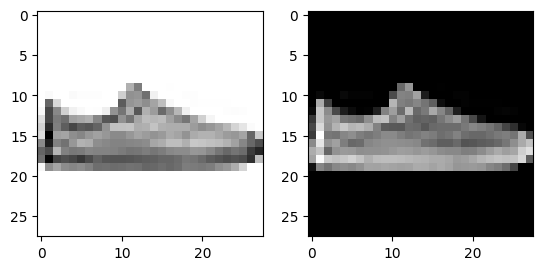

1/1 [==============================] - 0s 45ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


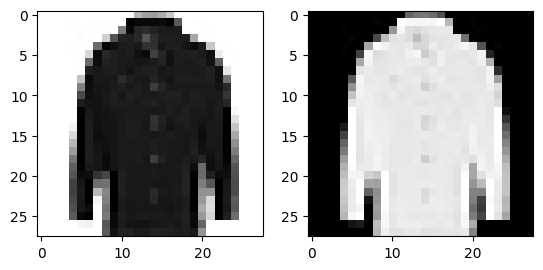

1/1 [==============================] - 0s 46ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


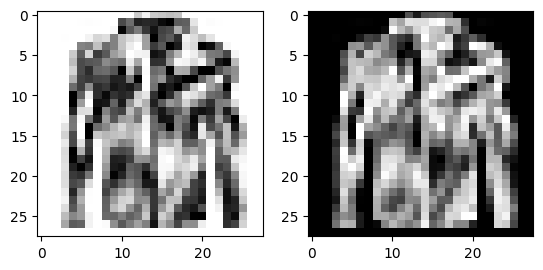

1/1 [==============================] - 0s 29ms/step
@@@ 오답 @@@
Y값 9. Ankle boot != 예측값 5. Sandal


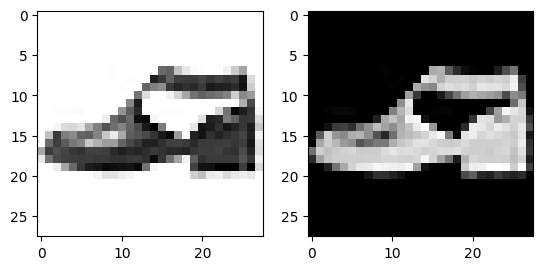

1/1 [==============================] - 0s 30ms/step
@@@ 오답 @@@
Y값 3. Dress != 예측값 6. Shirt


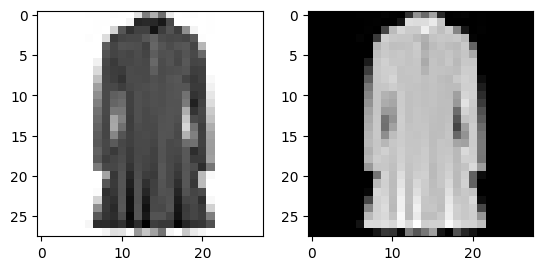

1/1 [==============================] - 0s 44ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 0. T-shirt/top


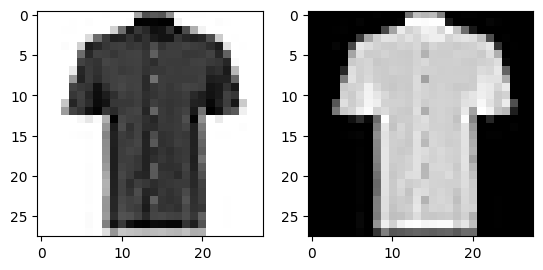

1/1 [==============================] - 0s 38ms/step
@@@ 오답 @@@
Y값 3. Dress != 예측값 6. Shirt


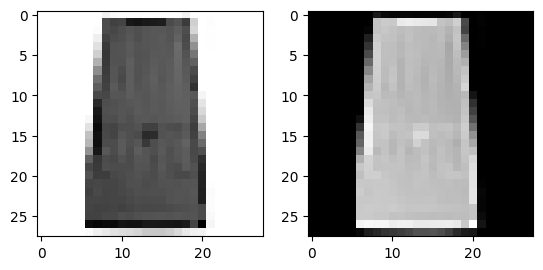

1/1 [==============================] - 0s 44ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 6. Shirt


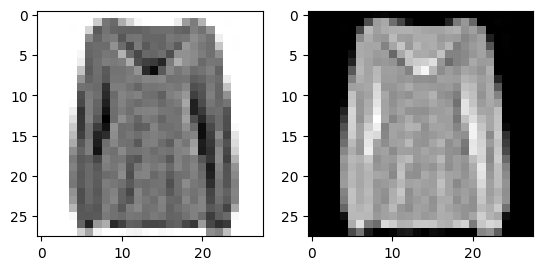

1/1 [==============================] - 0s 34ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


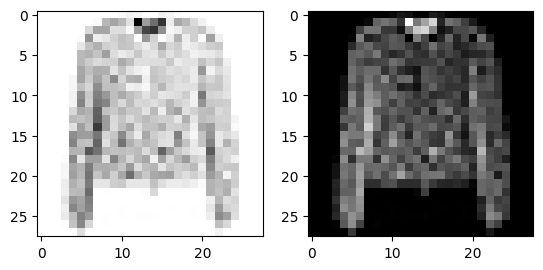

1/1 [==============================] - 0s 115ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 6. Shirt


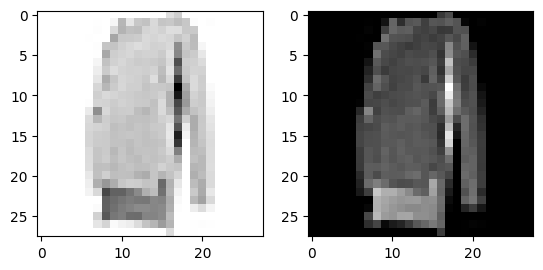

1/1 [==============================] - 0s 32ms/step
@@@ 오답 @@@
Y값 3. Dress != 예측값 4. Coat


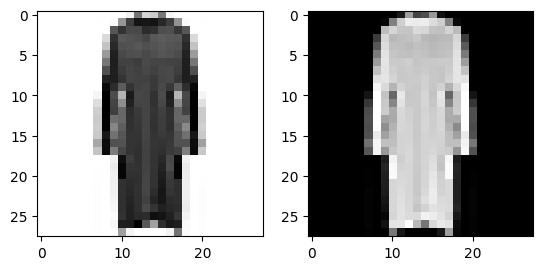

1/1 [==============================] - 0s 48ms/step
@@@ 오답 @@@
Y값 9. Ankle boot != 예측값 7. Sneaker


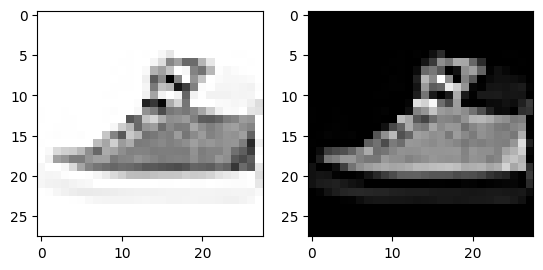

1/1 [==============================] - 0s 62ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 2. Pullover


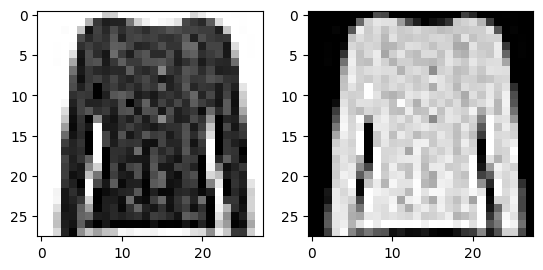

1/1 [==============================] - 0s 41ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


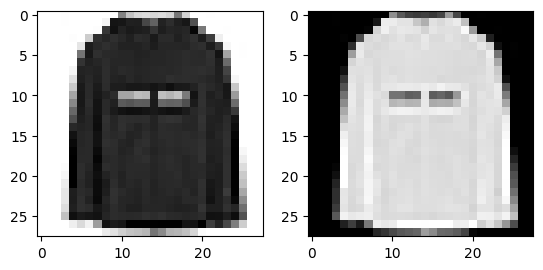

1/1 [==============================] - 0s 39ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 3. Dress


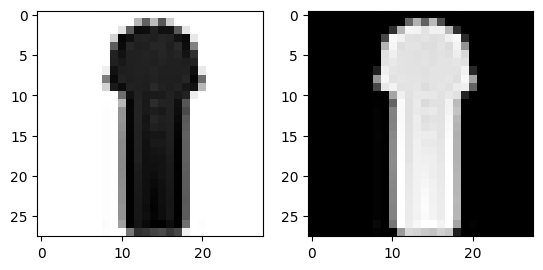

1/1 [==============================] - 0s 45ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 3. Dress


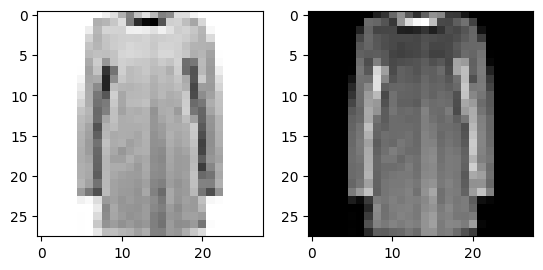

1/1 [==============================] - 0s 55ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 3. Dress


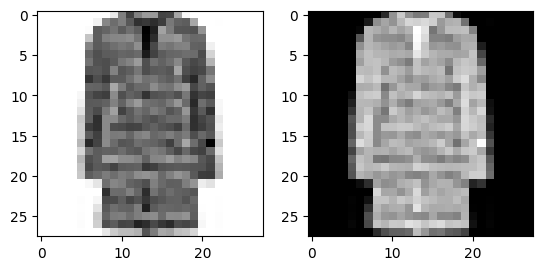

1/1 [==============================] - 0s 343ms/step
@@@ 오답 @@@
Y값 1. Trouser != 예측값 3. Dress


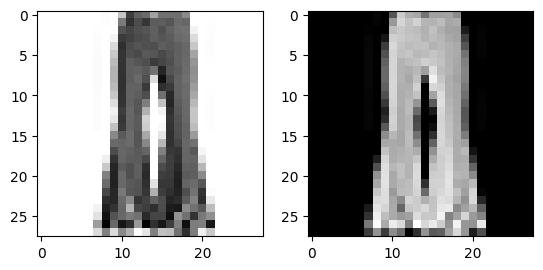

1/1 [==============================] - 0s 57ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


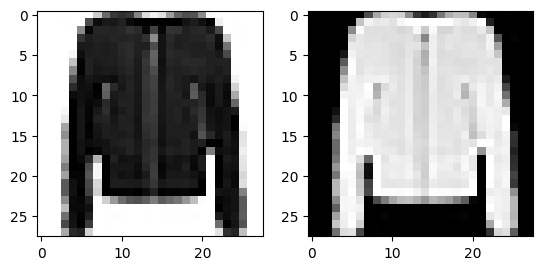

1/1 [==============================] - 0s 65ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 2. Pullover


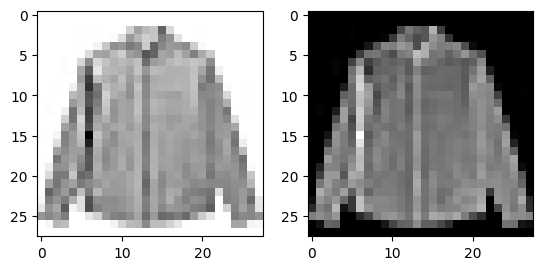

1/1 [==============================] - 0s 69ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 2. Pullover


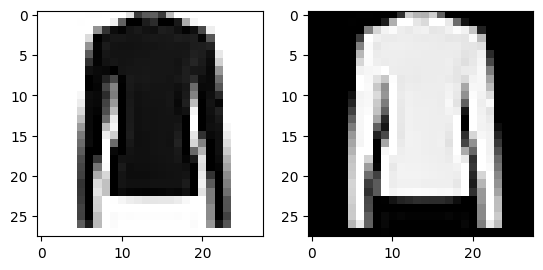

1/1 [==============================] - 0s 47ms/step
@@@ 오답 @@@
Y값 3. Dress != 예측값 6. Shirt


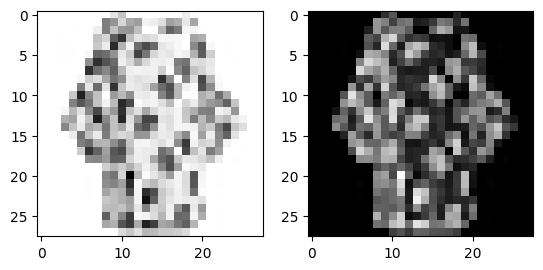

1/1 [==============================] - 0s 121ms/step
@@@ 오답 @@@
Y값 3. Dress != 예측값 4. Coat


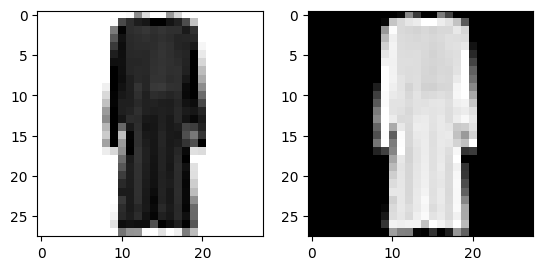

1/1 [==============================] - 0s 54ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 0. T-shirt/top


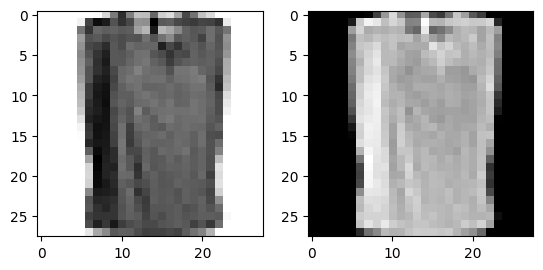

1/1 [==============================] - 0s 51ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 0. T-shirt/top


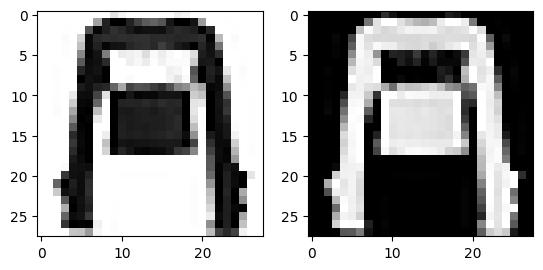

1/1 [==============================] - 0s 60ms/step
@@@ 오답 @@@
Y값 9. Ankle boot != 예측값 7. Sneaker


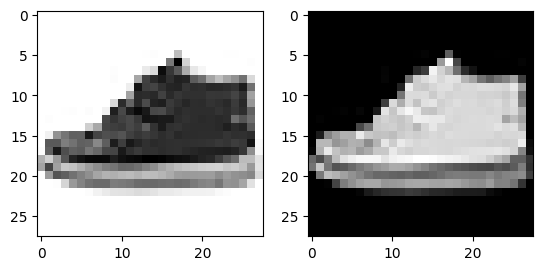

1/1 [==============================] - 0s 53ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 6. Shirt


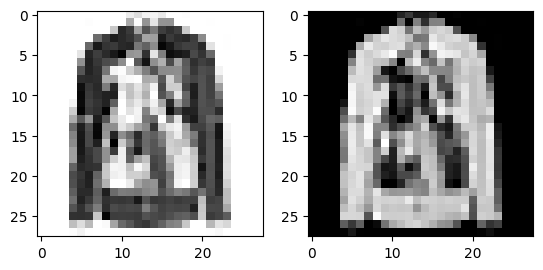

1/1 [==============================] - 0s 260ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 2. Pullover


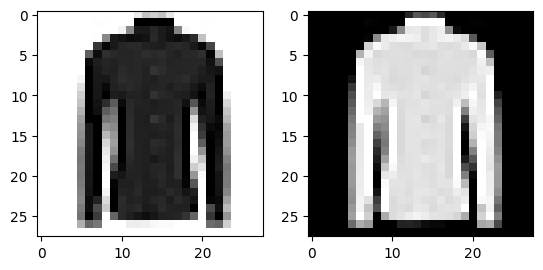

1/1 [==============================] - 0s 55ms/step
@@@ 오답 @@@
Y값 6. Shirt != 예측값 0. T-shirt/top


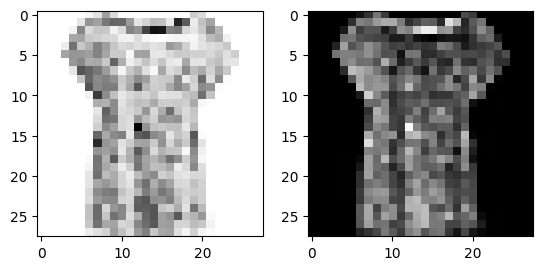

1/1 [==============================] - 0s 75ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 6. Shirt


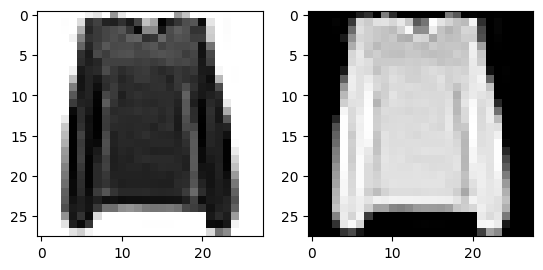

1/1 [==============================] - 0s 116ms/step
@@@ 오답 @@@
Y값 4. Coat != 예측값 2. Pullover


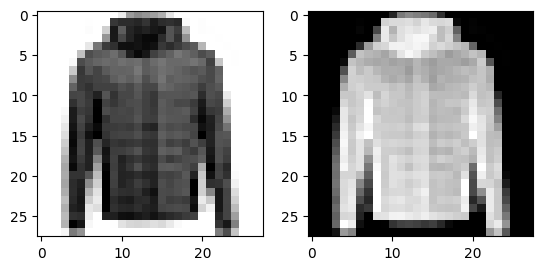

1/1 [==============================] - 0s 69ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 6. Shirt


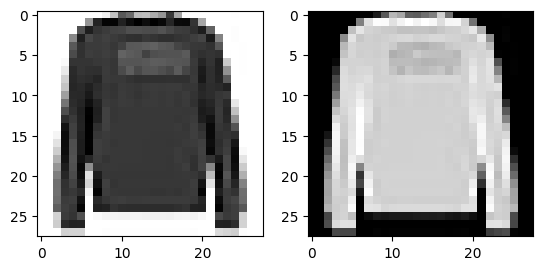

1/1 [==============================] - 0s 90ms/step
@@@ 오답 @@@
Y값 0. T-shirt/top != 예측값 6. Shirt


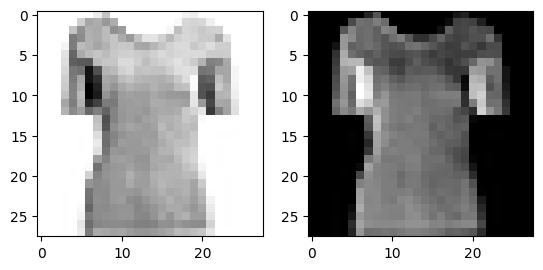

1/1 [==============================] - 0s 77ms/step
@@@ 오답 @@@
Y값 0. T-shirt/top != 예측값 6. Shirt


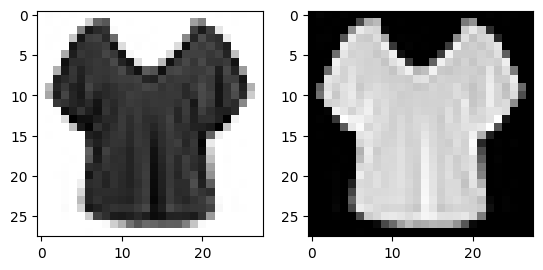

1/1 [==============================] - 0s 229ms/step
@@@ 오답 @@@
Y값 2. Pullover != 예측값 0. T-shirt/top


KeyboardInterrupt: 

In [22]:
#############################################################
# Test data 중 오답 print
#############################################################
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 
          'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 
for i in range(len(X_test)):
    predicted = model.predict(X_test[i].reshape(-1, 28*28)).argmax()
    if Y_test[i].argmax() != predicted:
        print("@@@ 오답 @@@")
        print(f"Y값 {Y_test[i].argmax()}. {labels[Y_test[i].argmax()]}" +
              f" != 예측값 {predicted}. {labels[predicted]}")
        plt.subplot(1, 2, 1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='Greys')
        plt.subplot(1, 2, 2)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')  
        plt.show()

In [ ]:
%%time
##############################################################
# 16-3 MNIST : Deep 코드  (28분 소요 / 15분?)
#  Test Accuracy: 0.9315
# CPU times: total: 1h 17min 21s
# Wall time: 15min 26s
##############################################################
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf

# 데이터 불러오기
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()  # fashion mnist
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train)
Y_test = tf.keras.utils.to_categorical(Y_test)

# 컨볼루션 신경망의 설정
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,  activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = './model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="./model/{epoch:02d}-{val_loss:.4f}.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', 
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), 
                    epochs=30, batch_size=50, verbose=2,            ## verbose=0? 2?
                    callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test)[1]))

# 그래프 그리기
pd.DataFrame(history.history).plot()
plt.show()

In [ ]:
##############################################################
# 16-3 MNIST : Deep 코드  (28분 소요)
##############################################################
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf

# 데이터 불러오기
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()  # fashion mnist
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train)
Y_test = tf.keras.utils.to_categorical(Y_test)

# 컨볼루션 신경망의 설정
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,  activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

In [ ]:
import numpy as np
train_args = np.random.choice(len(X_train), 6000)
test_args = np.random.choice(len(X_test), 1000)

In [ ]:
%%time
##############################################################
# 데이터를 1/10로 줄여서 해보기
# 16-3 MNIST : Deep 코드  (28분 소요 / 15분?)
# Test Accuracy: 0.8670
# CPU times: total: 7min 14s
# Wall time: 1min 26s
##############################################################
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf

# 데이터 불러오기
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()  # fashion mnist
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train)
Y_test = tf.keras.utils.to_categorical(Y_test)

## 신속한 테스트를 위해 데이터를 1/10 로 줄여서 해보기
import numpy as np
train_args = np.random.choice(len(X_train), 6000)
test_args = np.random.choice(len(X_test), 1000)
X_train, Y_train = X_train[train_args], Y_train[train_args]
X_test, Y_test = X_test[test_args], Y_test[test_args]

# 컨볼루션 신경망의 설정
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,  activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = './model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath="./model/{epoch:02d}-{val_loss:.4f}.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', 
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델의 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), 
                    epochs=30, batch_size=50, verbose=2,            ## verbose=0? 2?
                    callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도 출력
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, Y_test)[1]))

# 그래프 그리기
pd.DataFrame(history.history).plot()
plt.show()

In [ ]:
#############################################################
# Test data 중 오답 print
#############################################################
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 
          'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 
for i in range(len(X_test)):
    predicted = model.predict(X_test[i].reshape(-1, 28*28)).argmax()
    if Y_test[i].argmax() != predicted:
        print("@@@ 오답 @@@")
        print(f"Y값 {Y_test[i].argmax()}. {labels[Y_test[i].argmax()]}" +
              f" != 예측값 {predicted}. {labels[predicted]}")
        plt.subplot(1, 2, 1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='Greys')  
        plt.subplot(1, 2, 2)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')  
        plt.show()